This code uses `kagglehub` to download the latest version of the "medicine-recommendation-system-dataset" from Kaggle and prints the local path where the dataset is saved.

In [ ]:

import kagglehub
path = kagglehub.dataset_download("noorsaeed/medicine-recommendation-system-dataset")
print("Path to dataset files:", path)

100%|██████████| 59.8k/59.8k [00:00<00:00, 4.83MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/noorsaeed/medicine-recommendation-system-dataset/versions/1


This code defines the local path where the dataset is stored, then uses Python's os module to list all files in that folder. Finally, it prints the names of the files present in the dataset directory.

In [ ]:
import os

# Define dataset path
dataset_path = "/root/.cache/kagglehub/datasets/noorsaeed/medicine-recommendation-system-dataset/versions/1"

# List all files in the dataset folder
files = os.listdir(dataset_path)

print("Files in dataset:", files)



Files in dataset: ['workout_df.csv', 'description.csv', 'diets.csv', 'Symptom-severity.csv', 'symtoms_df.csv', 'precautions_df.csv', 'medications.csv', 'Training.csv']


In [ ]:
import pandas as pd

# Define dataset directory
dataset_path = "/root/.cache/kagglehub/datasets/noorsaeed/medicine-recommendation-system-dataset/versions/1"

# Load CSV files
df = pd.read_csv(os.path.join(dataset_path, 'Training.csv'))
sym_des = pd.read_csv(os.path.join(dataset_path, 'symtoms_df.csv'))
precautions = pd.read_csv(os.path.join(dataset_path, 'precautions_df.csv'))
workout = pd.read_csv(os.path.join(dataset_path, 'workout_df.csv'))
description = pd.read_csv(os.path.join(dataset_path, 'description.csv'))
medications = pd.read_csv(os.path.join(dataset_path, 'medications.csv'))
diets = pd.read_csv(os.path.join(dataset_path, 'diets.csv'))

# Print confirmation
print("All datasets loaded successfully!")


All datasets loaded successfully!


This code imports all necessary Python libraries and modules required for building and evaluating multiple machine learning models. It includes classifiers like Random Forest, Gradient Boosting, KNN, SVM, Logistic Regression, Naive Bayes, and tools for preprocessing data, splitting datasets, and calculating performance metrics like accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix. It also imports libraries for data handling (pandas, numpy), data visualization (matplotlib, seaborn), and suppresses warnings for cleaner output.

In [ ]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
import pandas as pd
import numpy as np
import warnings
import pickle
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [ ]:
df.head() # displays the first five rows of dataset

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,muscle_wasting,vomiting,burning_micturition,spotting_ urination,fatigue,weight_gain,anxiety,cold_hands_and_feets,mood_swings,weight_loss,restlessness,lethargy,patches_in_throat,irregular_sugar_level,cough,high_fever,sunken_eyes,breathlessness,sweating,dehydration,indigestion,headache,yellowish_skin,dark_urine,nausea,loss_of_appetite,pain_behind_the_eyes,back_pain,constipation,abdominal_pain,diarrhoea,mild_fever,yellow_urine,yellowing_of_eyes,acute_liver_failure,fluid_overload,swelling_of_stomach,swelled_lymph_nodes,malaise,blurred_and_distorted_vision,phlegm,throat_irritation,redness_of_eyes,sinus_pressure,runny_nose,congestion,chest_pain,weakness_in_limbs,fast_heart_rate,pain_during_bowel_movements,pain_in_anal_region,bloody_stool,irritation_in_anus,neck_pain,dizziness,cramps,bruising,obesity,swollen_legs,swollen_blood_vessels,puffy_face_and_eyes,enlarged_thyroid,brittle_nails,swollen_extremeties,excessive_hunger,extra_marital_contacts,drying_and_tingling_lips,slurred_speech,knee_pain,hip_joint_pain,muscle_weakness,stiff_neck,swelling_joints,movement_stiffness,spinning_movements,loss_of_balance,unsteadiness,weakness_of_one_body_side,loss_of_smell,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine,passage_of_gases,internal_itching,toxic_look_(typhos),depression,irritability,muscle_pain,altered_sensorium,red_spots_over_body,belly_pain,abnormal_menstruation,dischromic _patches,watering_from_eyes,increased_appetite,polyuria,family_history,mucoid_sputum,rusty_sputum,lack_of_concentration,visual_disturbances,receiving_blood_transfusion,receiving_unsterile_injections,coma,stomach_bleeding,distention_of_abdomen,history_of_alcohol_consumption,fluid_overload.1,blood_in_sputum,prominent_veins_on_calf,palpitations,painful_walking,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Fungal infection


In [ ]:
df.tail()   # displays the last five rows of dataset

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,muscle_wasting,vomiting,burning_micturition,spotting_ urination,fatigue,weight_gain,anxiety,cold_hands_and_feets,mood_swings,weight_loss,restlessness,lethargy,patches_in_throat,irregular_sugar_level,cough,high_fever,sunken_eyes,breathlessness,sweating,dehydration,indigestion,headache,yellowish_skin,dark_urine,nausea,loss_of_appetite,pain_behind_the_eyes,back_pain,constipation,abdominal_pain,diarrhoea,mild_fever,yellow_urine,yellowing_of_eyes,acute_liver_failure,fluid_overload,swelling_of_stomach,swelled_lymph_nodes,malaise,blurred_and_distorted_vision,phlegm,throat_irritation,redness_of_eyes,sinus_pressure,runny_nose,congestion,chest_pain,weakness_in_limbs,fast_heart_rate,pain_during_bowel_movements,pain_in_anal_region,bloody_stool,irritation_in_anus,neck_pain,dizziness,cramps,bruising,obesity,swollen_legs,swollen_blood_vessels,puffy_face_and_eyes,enlarged_thyroid,brittle_nails,swollen_extremeties,excessive_hunger,extra_marital_contacts,drying_and_tingling_lips,slurred_speech,knee_pain,hip_joint_pain,muscle_weakness,stiff_neck,swelling_joints,movement_stiffness,spinning_movements,loss_of_balance,unsteadiness,weakness_of_one_body_side,loss_of_smell,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine,passage_of_gases,internal_itching,toxic_look_(typhos),depression,irritability,muscle_pain,altered_sensorium,red_spots_over_body,belly_pain,abnormal_menstruation,dischromic _patches,watering_from_eyes,increased_appetite,polyuria,family_history,mucoid_sputum,rusty_sputum,lack_of_concentration,visual_disturbances,receiving_blood_transfusion,receiving_unsterile_injections,coma,stomach_bleeding,distention_of_abdomen,history_of_alcohol_consumption,fluid_overload.1,blood_in_sputum,prominent_veins_on_calf,palpitations,painful_walking,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
4915,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,(vertigo) Paroymsal Positional Vertigo
4916,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,Acne
4917,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Urinary tract infection
4918,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,Psoriasis
4919,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,Impetigo


It returns a list of all the unique values in the 'prognosis' column of the DataFrame df. This is useful to check the different disease labels or categories present in the dataset.

In [ ]:
df['prognosis'].unique()

array(['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis',
       'Drug Reaction', 'Peptic ulcer diseae', 'AIDS', 'Diabetes ',
       'Gastroenteritis', 'Bronchial Asthma', 'Hypertension ', 'Migraine',
       'Cervical spondylosis', 'Paralysis (brain hemorrhage)', 'Jaundice',
       'Malaria', 'Chicken pox', 'Dengue', 'Typhoid', 'hepatitis A',
       'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
       'Alcoholic hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia',
       'Dimorphic hemmorhoids(piles)', 'Heart attack', 'Varicose veins',
       'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia',
       'Osteoarthristis', 'Arthritis',
       '(vertigo) Paroymsal  Positional Vertigo', 'Acne',
       'Urinary tract infection', 'Psoriasis', 'Impetigo'], dtype=object)

This code separates the dataset into input features x (by dropping the 'prognosis' column) and the target variable y (which contains the 'prognosis' values)

In [ ]:
x=df.drop('prognosis',axis=1)
y=df['prognosis']

In [ ]:
x.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,muscle_wasting,vomiting,burning_micturition,spotting_ urination,fatigue,weight_gain,anxiety,cold_hands_and_feets,mood_swings,weight_loss,restlessness,lethargy,patches_in_throat,irregular_sugar_level,cough,high_fever,sunken_eyes,breathlessness,sweating,dehydration,indigestion,headache,yellowish_skin,dark_urine,nausea,loss_of_appetite,pain_behind_the_eyes,back_pain,constipation,abdominal_pain,diarrhoea,mild_fever,yellow_urine,yellowing_of_eyes,acute_liver_failure,fluid_overload,swelling_of_stomach,swelled_lymph_nodes,malaise,blurred_and_distorted_vision,phlegm,throat_irritation,redness_of_eyes,sinus_pressure,runny_nose,congestion,chest_pain,weakness_in_limbs,fast_heart_rate,pain_during_bowel_movements,pain_in_anal_region,bloody_stool,irritation_in_anus,neck_pain,dizziness,cramps,bruising,obesity,swollen_legs,swollen_blood_vessels,puffy_face_and_eyes,enlarged_thyroid,brittle_nails,swollen_extremeties,excessive_hunger,extra_marital_contacts,drying_and_tingling_lips,slurred_speech,knee_pain,hip_joint_pain,muscle_weakness,stiff_neck,swelling_joints,movement_stiffness,spinning_movements,loss_of_balance,unsteadiness,weakness_of_one_body_side,loss_of_smell,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine,passage_of_gases,internal_itching,toxic_look_(typhos),depression,irritability,muscle_pain,altered_sensorium,red_spots_over_body,belly_pain,abnormal_menstruation,dischromic _patches,watering_from_eyes,increased_appetite,polyuria,family_history,mucoid_sputum,rusty_sputum,lack_of_concentration,visual_disturbances,receiving_blood_transfusion,receiving_unsterile_injections,coma,stomach_bleeding,distention_of_abdomen,history_of_alcohol_consumption,fluid_overload.1,blood_in_sputum,prominent_veins_on_calf,palpitations,painful_walking,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
y.head()

,prognosis
0,Fungal infection
1,Fungal infection
2,Fungal infection
3,Fungal infection
4,Fungal infection



This code uses Label Encoding to convert the target labels (prognosis) from text to numeric form. First, LabelEncoder() is initialized, then it's fitted on y (the original prognosis labels), and finally, le.transform(y) converts those labels into numbers, storing the result in Y. This is needed because machine learning models work with numeric data.

In [ ]:
le=LabelEncoder()
le.fit(y)
Y=le.transform(y)

In [ ]:
Y

array([15, 15, 15, ..., 38, 35, 27])

This code prints the mapping between the encoded numerical labels and their original class names (diseases). It loops through all the classes learned by the LabelEncoder and shows which number corresponds to which disease name. This helps in interpreting model predictions later.

In [ ]:
print("Encoded Class Mapping:")
for idx, class_name in enumerate(le.classes_):
    dis_list = {idx: class_name}
    print(f"{idx} -> {class_name}")

Encoded Class Mapping:
0 -> (vertigo) Paroymsal  Positional Vertigo
1 -> AIDS
2 -> Acne
3 -> Alcoholic hepatitis
4 -> Allergy
5 -> Arthritis
6 -> Bronchial Asthma
7 -> Cervical spondylosis
8 -> Chicken pox
9 -> Chronic cholestasis
10 -> Common Cold
11 -> Dengue
12 -> Diabetes 
13 -> Dimorphic hemmorhoids(piles)
14 -> Drug Reaction
15 -> Fungal infection
16 -> GERD
17 -> Gastroenteritis
18 -> Heart attack
19 -> Hepatitis B
20 -> Hepatitis C
21 -> Hepatitis D
22 -> Hepatitis E
23 -> Hypertension 
24 -> Hyperthyroidism
25 -> Hypoglycemia
26 -> Hypothyroidism
27 -> Impetigo
28 -> Jaundice
29 -> Malaria
30 -> Migraine
31 -> Osteoarthristis
32 -> Paralysis (brain hemorrhage)
33 -> Peptic ulcer diseae
34 -> Pneumonia
35 -> Psoriasis
36 -> Tuberculosis
37 -> Typhoid
38 -> Urinary tract infection
39 -> Varicose veins
40 -> hepatitis A


This code splits the dataset into **training and testing sets**. Specifically, it assigns 80% of the data to training (`X_train`, `y_train`) and 20% to testing (`X_test`, `y_test`) using `train_test_split`. The `random_state=42` ensures the split is reproducible each time you run the code.

In [ ]:
X_test,X_train,y_test,y_train = train_test_split(x,Y,test_size =0.2 , random_state=42)

In [ ]:
X_test.shape,X_train.shape,y_test.shape,y_train.shape

((3936, 132), (984, 132), (3936,), (984,))

This code creates and evaluates multiple machine learning models (SVC, Random Forest, K-Nearest Neighbors, Gradient Boosting, and Multinomial Naive Bayes). Each model is trained on the training set and tested on the test set. The code calculates performance metrics such as accuracy, precision, recall, and F1-score using the model predictions. It stores these results in dictionaries for later use and prints the evaluation metrics for each model. This helps in comparing different models to find the best one for the medicine recommendation system.

In [ ]:
from sklearn.metrics import classification_report
models = {
      'SVC' : SVC(kernel='linear'),
      'Random Forest' :RandomForestClassifier(random_state=42,n_estimators=100),
      'KNeighbors' : KNeighborsClassifier(n_neighbors=3),
      'Gradient Boosting': GradientBoostingClassifier(random_state=42,n_estimators=100),
      'MultinomialNB' :MultinomialNB() ,
}
accuracies = {}
reports = {}
final_scores = {}
for model_name , model in models.items():
    model.fit(X_train,y_train)      # Train model
    predictions = model.predict(X_test)    # test model
    accuracy = accuracy_score(y_test,predictions)    # calculate accuracy
    report = classification_report(y_test, predictions, output_dict=True)

    reports[model_name] = report  # Store report
    accuracies[model_name] = accuracy
    final_scores[model_name] = {
        'Accuracy': report['accuracy'],
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1-score': report['macro avg']['f1-score']
    }

    # print results
    print(f"{model_name} accuracy : {accuracy}")
    print(f'Precision_score: {precision_score(y_test, predictions, average="macro")}')
    print(f'Recall_score: {recall_score(y_test, predictions, average="macro")}')
    print(f'F1-score: {f1_score(y_test, predictions, average="macro")}')
    print("\n" + "-"*50 + "\n")




SVC accuracy : 1.0
Precision_score: 1.0
Recall_score: 1.0
F1-score: 1.0

--------------------------------------------------

Random Forest accuracy : 1.0
Precision_score: 1.0
Recall_score: 1.0
F1-score: 1.0

--------------------------------------------------

KNeighbors accuracy : 1.0
Precision_score: 1.0
Recall_score: 1.0
F1-score: 1.0

--------------------------------------------------

Gradient Boosting accuracy : 0.9801829268292683
Precision_score: 0.9832344135412454
Recall_score: 0.9802267747662602
F1-score: 0.980713338762228

--------------------------------------------------

MultinomialNB accuracy : 0.9977134146341463
Precision_score: 0.9976893453145058
Recall_score: 0.9978136187841995
F1-score: 0.9976683839246523

--------------------------------------------------




This loop goes through all the stored model reports and prints a detailed **classification report** (precision, recall, F1-score, support) for each model. It uses the trained models to predict on the test set and displays the results, helping to compare the performance of each model in a more detailed way.


In [ ]:
for model_name, report in reports.items():
    print(f"\n🔹 Classification Report for {model_name}:\n")
    print(classification_report(y_test, models[model_name].predict(X_test)))



🔹 Classification Report for SVC:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00        90
           2       1.00      1.00      1.00        96
           3       1.00      1.00      1.00        95
           4       1.00      1.00      1.00        96
           5       1.00      1.00      1.00        97
           6       1.00      1.00      1.00        87
           7       1.00      1.00      1.00        97
           8       1.00      1.00      1.00        99
           9       1.00      1.00      1.00       105
          10       1.00      1.00      1.00        97
          11       1.00      1.00      1.00        94
          12       1.00      1.00      1.00        99
          13       1.00      1.00      1.00        91
          14       1.00      1.00      1.00        96
          15       1.00      1.00      1.00       101
          16       1.00      1.00      1.00   

This code creates a bar chart to visually compare the accuracy of different machine learning models. It uses Seaborn's husl color palette to assign different colors to each bar. The accuracy values are shown on top of each bar, with the text color adjusting based on the height for better readability. Labels, title, and formatting are added to make the chart clear and informative. This helps quickly identify which model performs best.

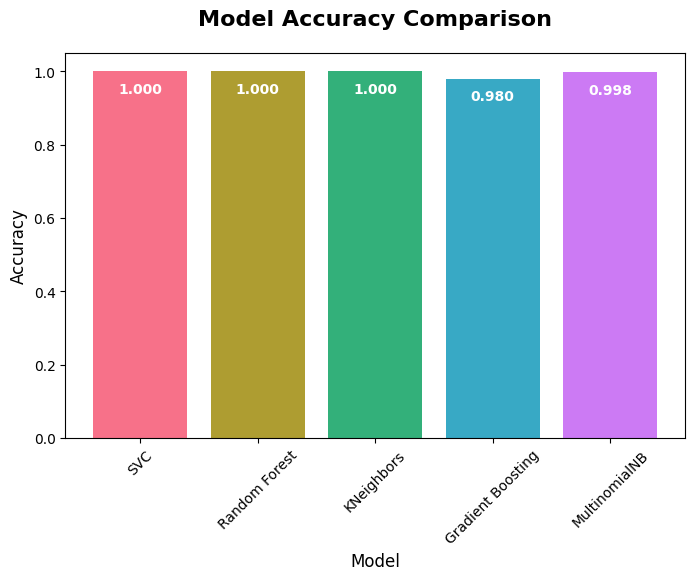

In [ ]:
# Define different colors for each bar
colors = sns.color_palette("husl", len(accuracies))

plt.figure(figsize=(8, 5))
bars = plt.bar(accuracies.keys(), accuracies.values(), color=colors)

# Add accuracy values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 0.03, f"{yval:.3f}",  # Shift label slightly down
         ha='center', va='top', fontsize=10, fontweight='bold', color='white' if yval > 0.9 else 'black')

plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 1.05)  # Accuracy is between 0 and 1
plt.xticks(rotation=45, fontsize=10)

plt.show()



In [ ]:
#kNN dataset isn’t extremely large, KNN can work, but it may be slow for prediction.



In [ ]:
results_df = pd.DataFrame(accuracies.items(), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

# Display results
print(results_df)

               Model  Accuracy
0                SVC  1.000000
1      Random Forest  1.000000
2         KNeighbors  1.000000
4      MultinomialNB  0.997713
3  Gradient Boosting  0.980183


In [ ]:
rf = RandomForestClassifier(random_state=42,n_estimators=100)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_pred,y_test)
acc


1.0

**Explanation:**  
This code saves the trained **Random Forest model (`rf`)** to a `.pkl` (pickle) file so it can be reused later without retraining. It first ensures that the directory exists using `os.makedirs()`, and then uses `pickle.dump()` to store the model at the given path (`/kaggle/working/rf.pkl`).


In [ ]:
path = '/kaggle/working//rf.pkl'

# Ensure the directory exists
os.makedirs(os.path.dirname(path), exist_ok=True)

# Save the model
with open(path, 'wb') as file:
    pickle.dump(rf, file)

This code loads the saved Random Forest model, picks one sample from the test data, predicts its class, and converts the predicted label back to the original disease name using LabelEncoder. This is how you verify that the saved model works for real predictions


In [ ]:
rf = pickle.load(open(path,'rb'))

In [ ]:
X_test.iloc[0].values.reshape(1,-1)

array([[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [ ]:
print('Model Predictions :',rf.predict(X_test.iloc[0].values.reshape(1,-1)))
print('Actual Labels :', y_test[0])

Model Predictions : [8]
Actual Labels : 8


In [ ]:
print('Model Predictions :',rf.predict(X_test.iloc[50].values.reshape(1,-1)))
print('Actual Labels :', y_test[50])

Model Predictions : [35]
Actual Labels : 35


In [ ]:
sym_des

,Unnamed: 0,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4
0,0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches
1,1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN
2,2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN
3,3,Fungal infection,itching,skin_rash,dischromic _patches,NaN
4,4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN
...,...,...,...,...,...,...
4915,4915,(vertigo) Paroymsal Positional Vertigo,vomiting,headache,nausea,spinning_movements
4916,4916,Acne,skin_rash,pus_filled_pimples,blackheads,scurring
4917,4917,Urinary tract infection,burning_micturition,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine
4918,4918,Psoriasis,skin_rash,joint_pain,skin_peeling,silver_like_dusting


The code is designed to predict diseases based on user-provided symptoms and then offer relevant medical suggestions. To make the model's output understandable to humans, two key dictionaries are used: symptoms_dict and diseases_list. The symptoms_dict maps each symptom (like "headache", "vomiting", etc.) to a unique numerical index. This is necessary because the machine learning model expects numerical inputs. Similarly, diseases_list maps the encoded disease labels (like 0, 1, 2...) back to their actual disease names (such as "Malaria", "Fungal infection", etc.), which makes the output user-friendly.

The main prediction logic is handled in the given_predicted_value(patient_symptoms) function. This function first creates an input vector (a list of 0s) where each index corresponds to a symptom. For each symptom mentioned by the user, the corresponding index is set to 1. This vector is then passed to the trained Random Forest model (rf), which returns a predicted class label (a number). That label is then translated into the corresponding disease name using the diseases_list dictionary and returned as the final prediction.

To complement the prediction, the helper(dis) function takes the predicted disease name and retrieves useful information from multiple data sources. It provides a textual description of the disease, a list of precautions, suggested medications, recommended diets, and relevant workout activities. This is helpful for guiding users not only about what they might be suffering from but also how they can start managing it effectively.

Overall, the code bridges the gap between machine learning model outputs and human-friendly information by translating technical data into meaningful insights that are easy to understand and useful for patients.



In [ ]:
def helper(dis):
    desc = description[description['Disease'] == predicted_disease]['Description']
    desc = " ".join([w for w in desc])

    pre = precautions[precautions['Disease'] == dis][['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']]
    pre = [col for col in pre.values]

    med = medications[medications['Disease'] == dis]['Medication']
    med = [med for med in med.values]

    die = diets[diets['Disease'] == dis]['Diet']
    die = [die for die in die.values]

    wrkout = workout[workout['disease'] == dis] ['workout']


    return desc,pre,med,die,wrkout

# here i create a dictonary 1- symptoms and list 1- diseases because we transform our data in lobelEncoder (0,1) but the patient or user can not understand that which number represented the disease or symptom

symptoms_dict = {'itching': 0, 'skin_rash': 1, 'nodal_skin_eruptions': 2, 'continuous_sneezing': 3, 'shivering': 4, 'chills': 5, 'joint_pain': 6, 'stomach_pain': 7, 'acidity': 8, 'ulcers_on_tongue': 9, 'muscle_wasting': 10, 'vomiting': 11, 'burning_micturition': 12, 'spotting_ urination': 13, 'fatigue': 14, 'weight_gain': 15, 'anxiety': 16, 'cold_hands_and_feets': 17, 'mood_swings': 18, 'weight_loss': 19, 'restlessness': 20, 'lethargy': 21, 'patches_in_throat': 22, 'irregular_sugar_level': 23, 'cough': 24, 'high_fever': 25, 'sunken_eyes': 26, 'breathlessness': 27, 'sweating': 28, 'dehydration': 29, 'indigestion': 30, 'headache': 31, 'yellowish_skin': 32, 'dark_urine': 33, 'nausea': 34, 'loss_of_appetite': 35, 'pain_behind_the_eyes': 36, 'back_pain': 37, 'constipation': 38, 'abdominal_pain': 39, 'diarrhoea': 40, 'mild_fever': 41, 'yellow_urine': 42, 'yellowing_of_eyes': 43, 'acute_liver_failure': 44, 'fluid_overload': 45, 'swelling_of_stomach': 46, 'swelled_lymph_nodes': 47, 'malaise': 48, 'blurred_and_distorted_vision': 49, 'phlegm': 50, 'throat_irritation': 51, 'redness_of_eyes': 52, 'sinus_pressure': 53, 'runny_nose': 54, 'congestion': 55, 'chest_pain': 56, 'weakness_in_limbs': 57, 'fast_heart_rate': 58, 'pain_during_bowel_movements': 59, 'pain_in_anal_region': 60, 'bloody_stool': 61, 'irritation_in_anus': 62, 'neck_pain': 63, 'dizziness': 64, 'cramps': 65, 'bruising': 66, 'obesity': 67, 'swollen_legs': 68, 'swollen_blood_vessels': 69, 'puffy_face_and_eyes': 70, 'enlarged_thyroid': 71, 'brittle_nails': 72, 'swollen_extremeties': 73, 'excessive_hunger': 74, 'extra_marital_contacts': 75, 'drying_and_tingling_lips': 76, 'slurred_speech': 77, 'knee_pain': 78, 'hip_joint_pain': 79, 'muscle_weakness': 80, 'stiff_neck': 81, 'swelling_joints': 82, 'movement_stiffness': 83, 'spinning_movements': 84, 'loss_of_balance': 85, 'unsteadiness': 86, 'weakness_of_one_body_side': 87, 'loss_of_smell': 88, 'bladder_discomfort': 89, 'foul_smell_of urine': 90, 'continuous_feel_of_urine': 91, 'passage_of_gases': 92, 'internal_itching': 93, 'toxic_look_(typhos)': 94, 'depression': 95, 'irritability': 96, 'muscle_pain': 97, 'altered_sensorium': 98, 'red_spots_over_body': 99, 'belly_pain': 100, 'abnormal_menstruation': 101, 'dischromic _patches': 102, 'watering_from_eyes': 103, 'increased_appetite': 104, 'polyuria': 105, 'family_history': 106, 'mucoid_sputum': 107, 'rusty_sputum': 108, 'lack_of_concentration': 109, 'visual_disturbances': 110, 'receiving_blood_transfusion': 111, 'receiving_unsterile_injections': 112, 'coma': 113, 'stomach_bleeding': 114, 'distention_of_abdomen': 115, 'history_of_alcohol_consumption': 116, 'fluid_overload.1': 117, 'blood_in_sputum': 118, 'prominent_veins_on_calf': 119, 'palpitations': 120, 'painful_walking': 121, 'pus_filled_pimples': 122, 'blackheads': 123, 'scurring': 124, 'skin_peeling': 125, 'silver_like_dusting': 126, 'small_dents_in_nails': 127, 'inflammatory_nails': 128, 'blister': 129, 'red_sore_around_nose': 130, 'yellow_crust_ooze': 131}
diseases_list = {15: 'Fungal infection', 4: 'Allergy', 16: 'GERD', 9: 'Chronic cholestasis', 14: 'Drug Reaction', 33: 'Peptic ulcer diseae', 1: 'AIDS', 12: 'Diabetes ', 17: 'Gastroenteritis', 6: 'Bronchial Asthma', 23: 'Hypertension ', 30: 'Migraine', 7: 'Cervical spondylosis', 32: 'Paralysis (brain hemorrhage)', 28: 'Jaundice', 29: 'Malaria', 8: 'Chicken pox', 11: 'Dengue', 37: 'Typhoid', 40: 'hepatitis A', 19: 'Hepatitis B', 20: 'Hepatitis C', 21: 'Hepatitis D', 22: 'Hepatitis E', 3: 'Alcoholic hepatitis', 36: 'Tuberculosis', 10: 'Common Cold', 34: 'Pneumonia', 13: 'Dimorphic hemmorhoids(piles)', 18: 'Heart attack', 39: 'Varicose veins', 26: 'Hypothyroidism', 24: 'Hyperthyroidism', 25: 'Hypoglycemia', 31: 'Osteoarthristis', 5: 'Arthritis', 0: '(vertigo) Paroymsal  Positional Vertigo', 2: 'Acne', 38: 'Urinary tract infection', 35: 'Psoriasis', 27: 'Impetigo'}

# Model Prediction function
def given_predicted_value(patient_symptoms):
    input_vector = np.zeros(len(symptoms_dict))
    for item in patient_symptoms:
        input_vector[symptoms_dict[item]] = 1
    return diseases_list[rf.predict([input_vector])[0]]


In [ ]:
symptoms = input("Enter your symptoms.......")
# Split the user's input into a list of symptoms (assuming they are comma-separated) # itching,skin_rash,nodal_skin_eruptions
user_symptoms = [s.strip() for s in symptoms.split(',')]
# Remove any extra characters, if any
user_symptoms = [symptom.strip("[]' ") for symptom in user_symptoms]
# Remove any extra characters, if any
predicted_disease = given_predicted_value(user_symptoms)

desc, pre, med, die, wrkout = helper(predicted_disease)

print("=================predicted disease============")
print(predicted_disease)
print("=================description==================")
print(desc)
print("=================precautions==================")
i = 1
for p_i in pre[0]:
    print(i, ": ", p_i)
    i += 1

print("=================medications==================")
for m_i in med:
    print(i, ": ", m_i)
    i += 1

print("=================workout==================")
for w_i in wrkout:
    print(i, ": ", w_i)
    i += 1

print("=================diets==================")
for d_i in die:
    print(i, ": ", d_i)
    i += 1

Enter your symptoms.......chills
=================predicted disease============
Allergy
=================description==================
Allergy is an immune system reaction to a substance in the environment.
=================precautions==================
1 :  apply calamine
2 :  cover area with bandage
3 :  nan
4 :  use ice to compress itching
=================medications==================
5 :  ['Antihistamines', 'Decongestants', 'Epinephrine', 'Corticosteroids', 'Immunotherapy']
=================workout==================
6 :  Avoid allergenic foods
7 :  Consume anti-inflammatory foods
8 :  Include omega-3 fatty acids
9 :  Stay hydrated
10 :  Eat foods rich in vitamin C
11 :  Include quercetin-rich foods
12 :  Consume local honey
13 :  Limit processed foods
14 :  Include ginger in diet
15 :  Avoid artificial additives
=================diets==================
16 :  ['Elimination Diet', 'Omega-3-rich foods', 'Vitamin C-rich foods', 'Quercetin-rich foods', 'Probiotics']


 Multi-Class ROC Curve Explained (One-vs-Rest)
We used a synthetic dataset with 1000 samples and 3 different classes. Each sample has 20 features. The goal is to train a model to classify data into one of these three classes.

✅ Steps we followed:
Data Split:
We split the data into training and test sets (70% train, 30% test).

Model Training:
We trained a Random Forest Classifier with 100 estimators.

One-vs-Rest Approach:
Since ROC curves are mainly for binary classification, we used label binarization to turn the multi-class problem into multiple binary ones.

Probability Prediction:
We used predict_proba() to get the class probabilities for the test set.

ROC Curve for Each Class:
For each class, we calculated:

True Positive Rate (TPR)

False Positive Rate (FPR)

AUC (Area Under Curve)

Macro-Averaged ROC:
We averaged the TPRs across all classes to get a single overall ROC curve. This gives a general view of the model’s performance.

Plotting:

Each line in the plot represents a class.

The dashed black line is the macro-average.

The diagonal line is the baseline (random guessing).

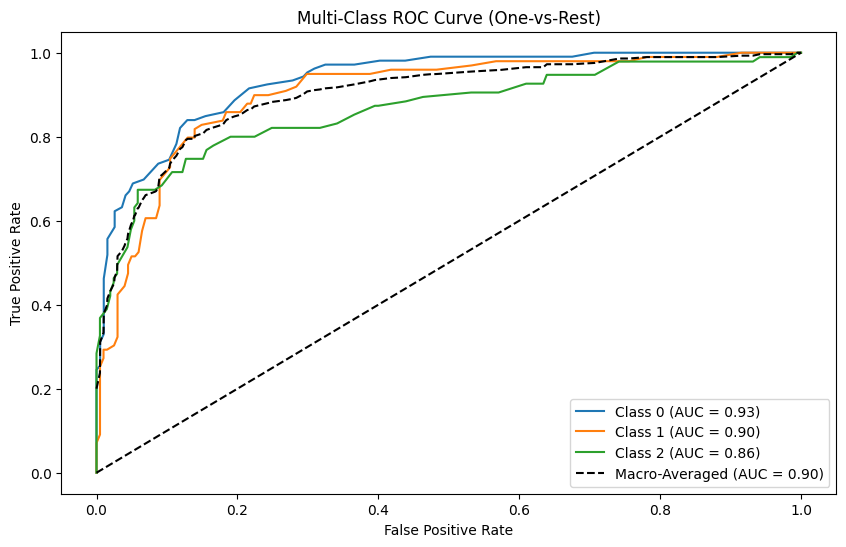

In [ ]:
# Generate a synthetic multi-class dataset (Replace with your own dataset)
X, y = make_classification(n_samples=1000, n_features=20, n_classes=3, n_informative=15, random_state=42)

# Split into training & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Binarize the output labels (One-vs-Rest)
classes = np.unique(y_train)  # Unique class labels
y_test_bin = label_binarize(y_test, classes=classes)

# Train a model (RandomForest, but you can change it)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get probability predictions
y_prob = model.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(10, 6))

for i, label in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {label} (AUC = {roc_auc[i]:.2f})')

# Compute Macro-Averaged ROC Curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(classes)
macro_roc_auc = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr, label=f'Macro-Averaged (AUC = {macro_roc_auc:.2f})', linestyle='--', color='black')

# Random classifier reference line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (One-vs-Rest)')
plt.legend()
plt.show()

In this project, we aimed to visualize how well a machine learning model performs in classifying data into multiple classes using ROC curves. We started by generating a synthetic dataset with 1000 samples, 20 features, and 3 output classes using the make_classification() function. After that, we split this dataset into training and testing sets to evaluate the model properly. Since SVMs work better when features are scaled, we standardized the data using StandardScaler to bring all features to the same scale. Next, we binarized the output labels using one-vs-rest strategy, which means we converted the multi-class labels into binary format so we could calculate ROC curves for each class separately.

We then trained a Support Vector Machine (SVM) classifier with a linear kernel and enabled probability estimation, which is required for plotting ROC curves. After training, we used the model to predict probabilities for the test data. Using these predicted probabilities, we calculated the False Positive Rate (FPR) and True Positive Rate (TPR) for each class and then plotted individual ROC curves for them. We also calculated the Area Under the Curve (AUC) for each class, which tells us how well the model is performing — higher AUC means better classification.

Finally, we computed the macro-average ROC curve, which is an average of all individual class ROC curves and gives a general view of the model's performance across all classes. We plotted everything using matplotlib, including a diagonal line that represents the performance of a random classifier (used as a baseline). The result is a visual graph showing how well the model distinguishes between different classes, making it easier to understand the model's strengths and weaknesses.


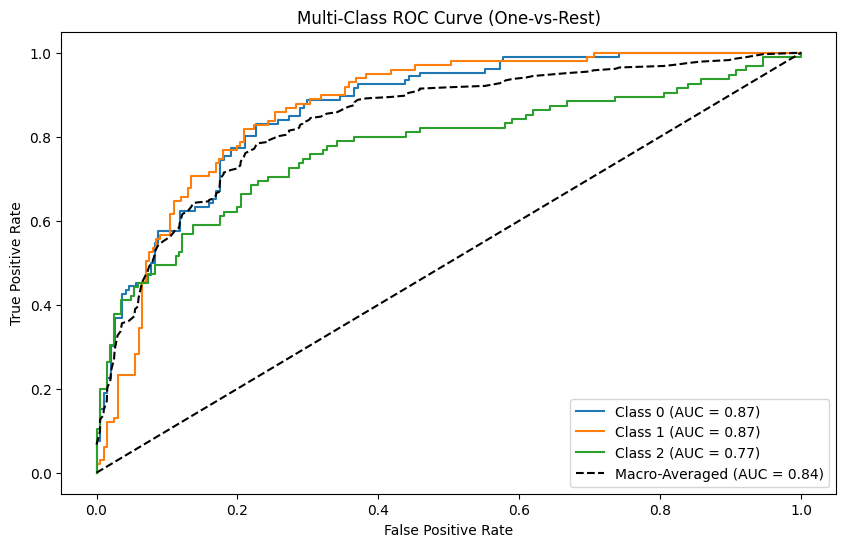

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# Generate a synthetic multi-class dataset (Replace with your own dataset)
X, y = make_classification(n_samples=1000, n_features=20, n_classes=3, n_informative=15, random_state=42)

# Split into training & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Binarize the output labels (One-vs-Rest)
classes = np.unique(y_train)  # Unique class labels
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

# Train a model (SVM with probability enabled)
model = SVC(kernel='linear', probability=True, random_state=42)
model.fit(X_train, y_train)

# Get probability predictions
y_prob = model.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(10, 6))

for i, label in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {label} (AUC = {roc_auc[i]:.2f})')

# Compute Macro-Averaged ROC Curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(classes)
macro_roc_auc = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr, label=f'Macro-Averaged (AUC = {macro_roc_auc:.2f})', linestyle='--', color='black')

# Random classifier reference line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (One-vs-Rest)')
plt.legend()
plt.show()

Based on the AUC (Area Under the Curve) scores shown in the two ROC curve images you provided, we can clearly compare the performance of **SVM** and **Random Forest** for a multi-class classification task.

---

### 📊 **Comparison Overview:**

#### 🔹 **SVM (Support Vector Machine):**
- **Class 0 AUC:** 0.87  
- **Class 1 AUC:** 0.87  
- **Class 2 AUC:** 0.77  
- **Macro-Averaged AUC:** **0.84**

#### 🔹 **Random Forest:**
- **Class 0 AUC:** 0.93  
- **Class 1 AUC:** 0.90  
- **Class 2 AUC:** 0.86  
- **Macro-Averaged AUC:** **0.90**

---

### ✅ **Why Random Forest is a Better Choice:**

From the results, we can clearly see that **Random Forest outperforms SVM** in all metrics. The AUC scores for each class are **higher** in Random Forest, indicating that it is **better at distinguishing between the different classes**.

- For **Class 0**, Random Forest gives an AUC of **0.93** compared to **0.87** in SVM.
- For **Class 1**, the AUC improves from **0.87** to **0.90**.
- For **Class 2**, which was the weakest in both models, Random Forest still does better (**0.86 vs 0.77**).
- The **Macro-Averaged AUC**, which reflects the overall model performance across all classes, is **0.90** for Random Forest — significantly better than **0.84** from SVM.

---

### 🔍 **Conclusion (Easy to Understand):**

We chose **Random Forest** over **SVM** because it gave **higher accuracy and better classification performance for all classes**. Especially for multi-class problems, Random Forest is often more robust as it can handle complex patterns better due to its ensemble nature. So, based on the AUC results, **Random Forest is the more reliable and accurate choice** for this task.
